# 04 — Rolling momentum: calibration shrinkage 0.40 vs 0.70

Same comparison as notebook 03, but both models are now `momentum_lookup_rolling`; they differ
only by `calibration_shrinkage` (the fraction of each bin's edge over 0.5 the model keeps when
it displays the curve).

- **shrinkage 0.40** — flatter displayed curve (keeps 40% of the edge).
- **shrinkage 0.70** — sharper displayed curve (keeps 70% of the edge).

Hypothesis: a flatter curve (0.40) under-states the directional probability, so it leaves more
edge on the table for an informed attacker. Both models share the same rolling window, so they
become valid on the same date and are compared from the common evaluation start with identical
windows and seeds.

In [1]:
import os
import sys

# Move up one level to the project root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
# Add the new current directory to the Python path
sys.path.insert(0, os.getcwd())

In [2]:
from snapmarket.data import load_oracle_prices
from snapmarket.features import build_features
from snapmarket.parameters import SharedParameters
from snapmarket.models import build_model
from snapmarket.models.momentum_lookup_rolling import MomentumLookupRollingParameters
from snapmarket.experiments import common_evaluation_start
from snapmarket.strategies import noise_pool
from snapmarket.engine import simulate

shared_parameters = SharedParameters()
features = build_features(load_oracle_prices(), shared_parameters)

shrinkage_values = {"shrinkage 0.40": 0.40, "shrinkage 0.70": 0.70}
models = {
    label: build_model("momentum_lookup_rolling", features, shared_parameters,
                       MomentumLookupRollingParameters(calibration_shrinkage=value))
    for label, value in shrinkage_values.items()
}
model_labels = list(models)
palette = ["#9ca3af", "#2563eb"]
color_map = {label: palette[index] for index, label in enumerate(model_labels)}

evaluation_start = common_evaluation_start(models.values())
print(f"common evaluation start: second {evaluation_start:,} (~{evaluation_start / 86_400:.0f} days in)")
for label, model in models.items():
    spread = model.display_probability[evaluation_start:]
    print(f"  {label}: displayed p_up range [{spread.min():.3f}, {spread.max():.3f}]")

common evaluation start: second 7,776,605 (~90 days in)
  shrinkage 0.40: displayed p_up range [0.434, 0.560]
  shrinkage 0.70: displayed p_up range [0.385, 0.605]


## Part 1 — Uninformed random flow

Non-overlapping windows of a balanced noise pool through both models with the same seed. With
uninformed flow the house edge should sit near the vig for both; the displayed curve barely
matters here.

In [3]:
import numpy as np
import pandas as pd

window_length = 200_000          # seconds per window
number_of_windows = 8            # raise for a longer evaluation

rows = []
for window_index in range(number_of_windows):
    start = evaluation_start + window_index * window_length
    if start + window_length + shared_parameters.horizon_seconds >= features.number_of_seconds:
        break
    seed = 1_000 + window_index
    for label, model in models.items():
        result = simulate(model, features, {"noise": noise_pool()}, start, window_length, seed=seed)
        rows.append({
            "window": window_index,
            "model": label,
            "house_edge": result.house_edge,
            "house_pnl": result.house_pnl,
            "volume": result.total_volume,
        })

results = pd.DataFrame(rows)
print(f"{results['window'].nunique()} windows of {window_length:,} seconds each")
results.pivot(index="window", columns="model", values="house_edge")[model_labels]

8 windows of 200,000 seconds each


model,shrinkage 0.40,shrinkage 0.70
window,,
0,0.128415,0.125305
1,0.131274,0.130621
2,0.125443,0.120029
3,0.127830,0.123956
4,0.130662,0.129004
5,0.128413,0.124099
6,0.126756,0.121291
7,0.127484,0.123583


In [4]:
summary = (results
           .groupby("model")
           .agg(mean_house_edge=("house_edge", "mean"),
                std_house_edge=("house_edge", "std"),
                total_house_pnl=("house_pnl", "sum"),
                total_volume=("volume", "sum"))
           .reindex(model_labels))
summary["aggregate_house_edge"] = summary["total_house_pnl"] / summary["total_volume"]

print(summary.to_string(formatters={
    "mean_house_edge": "{:+.3%}".format,
    "std_house_edge": "{:.3%}".format,
    "total_house_pnl": "${:,.0f}".format,
    "total_volume": "${:,.0f}".format,
    "aggregate_house_edge": "{:+.3%}".format,
}))

               mean_house_edge std_house_edge total_house_pnl total_volume aggregate_house_edge
model                                                                                          
shrinkage 0.40        +12.828%         0.192%     $10,254,556  $79,937,696             +12.828%
shrinkage 0.70        +12.474%         0.358%      $9,970,637  $79,937,696             +12.473%


Matplotlib is building the font cache; this may take a moment.


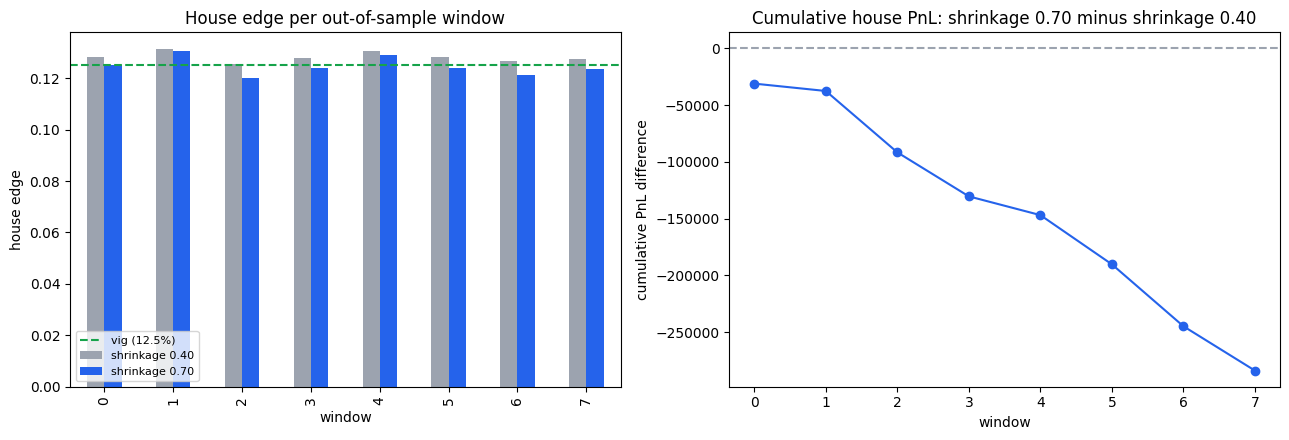

In [5]:
import matplotlib.pyplot as plt

edge_by_window = results.pivot(index="window", columns="model", values="house_edge")[model_labels]
house_pnl_by_window = results.pivot(index="window", columns="model", values="house_pnl")[model_labels]
pnl_difference = (house_pnl_by_window[model_labels[1]] - house_pnl_by_window[model_labels[0]]).cumsum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

edge_by_window.plot(kind="bar", ax=axes[0], color=color_map)
axes[0].axhline(shared_parameters.house_margin, ls="--", color="#16a34a",
                label=f"vig ({shared_parameters.house_margin:.1%})")
axes[0].set_title("House edge per out-of-sample window")
axes[0].set_xlabel("window"); axes[0].set_ylabel("house edge")
axes[0].legend(fontsize=8)

pnl_difference.plot(ax=axes[1], marker="o", color="#2563eb")
axes[1].axhline(0, ls="--", color="#9ca3af")
axes[1].set_title(f"Cumulative house PnL: {model_labels[1]} minus {model_labels[0]}")
axes[1].set_xlabel("window"); axes[1].set_ylabel("cumulative PnL difference")

plt.tight_layout(); plt.show()

## Part 2 — Informed attackers

The same three informed attackers as notebook 03, run inside a noise pool against each model.
The signals are model-independent, so they are built once and applied to both shrinkage settings.
If the hypothesis holds, the sharper 0.70 curve should give the attackers less edge — especially
the momentum-driven ones.

In [6]:
from snapmarket.data import load_fast_feed
from snapmarket.signals import walk_forward_logistic_probability, regime_conditional_probability
from snapmarket.strategies import predictive_bettor, lead_lag_bettor, regime_aware_bettor

fast_feed = load_fast_feed(expected_length=features.number_of_seconds)

logistic_probability = walk_forward_logistic_probability(features, shared_parameters)
regime_probability = regime_conditional_probability(features, shared_parameters)

informed_attackers = {
    "predictive (logistic)": predictive_bettor(logistic_probability),
    "lead-lag (fast feed)": lead_lag_bettor(features, fast_feed.log_price),
    "regime-aware": regime_aware_bettor(regime_probability),
}
print("informed attackers:", list(informed_attackers))

informed attackers: ['predictive (logistic)', 'lead-lag (fast feed)', 'regime-aware']


In [7]:
informed_window_length = 150_000
informed_number_of_windows = 6

attacker_rows = []
for model_label, model in models.items():
    for attacker_label, bettor in informed_attackers.items():
        attacker_pnl = attacker_stake = total_volume = 0.0
        for window_index in range(informed_number_of_windows):
            start = evaluation_start + window_index * informed_window_length
            if start + informed_window_length + shared_parameters.horizon_seconds >= features.number_of_seconds:
                break
            result = simulate(model, features,
                              {"pool": noise_pool(), "attacker": bettor},
                              start, informed_window_length, seed=200 + window_index)
            outcome = result.per_bettor["attacker"]
            attacker_pnl += outcome.pnl
            attacker_stake += outcome.stake
            total_volume += result.total_volume
        attacker_rows.append({
            "attacker": attacker_label,
            "model": model_label,
            "attacker_edge": attacker_pnl / attacker_stake if attacker_stake else 0.0,
            "volume_share": attacker_stake / total_volume if total_volume else 0.0,
        })

attacker_results = pd.DataFrame(attacker_rows)
attacker_edge = attacker_results.pivot(index="attacker", columns="model", values="attacker_edge")[model_labels]
attacker_edge

model,shrinkage 0.40,shrinkage 0.70
attacker,,
lead-lag (fast feed),-0.172596,-0.173444
predictive (logistic),-0.046773,-0.052506
regime-aware,0.046678,0.039718


In [8]:
print("Attacker edge (PnL / stake), positive = beats the house:\n")
print(attacker_edge.to_string(formatters={label: "{:+.2%}".format for label in model_labels}))

edge_change = 1e4 * (attacker_edge[model_labels[1]] - attacker_edge[model_labels[0]])
print(f"\nAttacker edge change from {model_labels[0]} to {model_labels[1]} (basis points):\n")
print(edge_change.to_string(float_format="{:+.0f}".format))

Attacker edge (PnL / stake), positive = beats the house:

model                 shrinkage 0.40 shrinkage 0.70
attacker                                           
lead-lag (fast feed)         -17.26%        -17.34%
predictive (logistic)         -4.68%         -5.25%
regime-aware                  +4.67%         +3.97%

Attacker edge change from shrinkage 0.40 to shrinkage 0.70 (basis points):

attacker
lead-lag (fast feed)     -8
predictive (logistic)   -57
regime-aware            -70


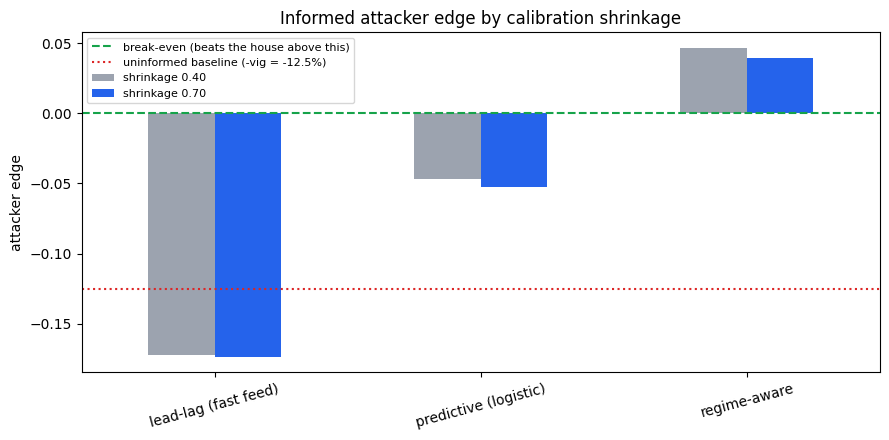

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
attacker_edge.plot(kind="bar", ax=ax, color=color_map)
ax.axhline(0, color="#16a34a", ls="--", label="break-even (beats the house above this)")
ax.axhline(-shared_parameters.house_margin, color="#dc2626", ls=":",
           label=f"uninformed baseline (-vig = {-shared_parameters.house_margin:.1%})")
ax.set_title("Informed attacker edge by calibration shrinkage")
ax.set_ylabel("attacker edge"); ax.set_xlabel("")
ax.legend(fontsize=8)
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()